<a href="https://colab.research.google.com/github/Eno-stack/MLU/blob/main/math_lecture03_lab01_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align: right; font-family: Arial;"><hr width="15%" align="right" style="margin-bottom: -0.8em;"><h4>City Colleges of Chicago <h4></div>

<p style="padding: 10px; border: 1px solid black;">
<div style="background-image: linear-gradient(145deg, rgba(35, 47, 62, 1) 0%, rgba(51, 0, 102, 1) 40%, rgba(223, 42, 93, 1) 60%, rgba(124, 90, 237, 1) 85%, rgba(124, 232, 244, 1) 100%); padding: 20px; border-radius: 10px; text-align: center; margin-bottom: 30px;">
    <h1 style="color: white; margin: 0;">MLU: Mathematical Fundamentals for Machine Learning</h1>
    <h2 style="color: white; margin-top: 15px;">Basic Concepts of Probability</h2>
</div>

<!-- Compact Lab Introduction with Activity/Challenge Explanation -->
<div style="background-color: #F8F9F9; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <h4 style="color: #2E4053; margin-top: 0;">About This Lab</h4>
    <p>Throughout this lab, you will encounter two types of interactive elements:</p>
    <table style="width: 100%; border-collapse: collapse; margin: 15px 0;">
        <tr>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="images/mlu-activity.png" alt="Activity" width="125"/>
            </td>
            <td style="text-align: center; padding: 10px; width: 50%;">
                <img src="images/mlu-challenge.png" alt="Challenge" width="125"/>
            </td>
        </tr>
        <tr>
            <td style="text-align: center; padding: 10px; background-color: #EBF5FB;">
                <p>No coding is needed for an activity. You try to understand a concept, <br/>answer questions, or run a code cell.</p>
            </td>
            <td style="text-align: center; padding: 10px; background-color: #FEF9E7;">
                <p>Challenges are where you test your understanding by implementing something new or taking a short quiz.</p>
            </td>
        </tr>
    </table>
    <p>Please work through this notebook from top to bottom to avoid errors due to missing code or context.</p>
</div>

<!-- Table of Contents with All Section Levels -->
<div style="background-color: #f2f0fc; padding: 15px; border-radius: 5px; margin-bottom: 30px;">
    <h2 style="color: #2f1381; border-bottom: 1px solid #2f1381; padding-bottom: 5px;">Table of Contents</h2>
    <p><a href="#section1" style="color: #2f1381; font-weight: bold; text-decoration: none;">1. Probability Model</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section1-1" style="color: #2f1381; text-decoration: none;">1.1 Classical Approach</a></li>
        <li><a href="#section1-2" style="color: #2f1381; text-decoration: none;">1.2 Frequentist Approach</a></li>
    </ul>
    <p><a href="#section2" style="color: #2f1381; font-weight: bold; text-decoration: none;">2. Bayes Theorem</a></p>
    <ul style="margin-top: 0; padding-left: 30px;">
        <li><a href="#section2-1" style="color: #2f1381; text-decoration: none;">2.1 Bayes Theorem: Formulation</a></li>
        <li><a href="#section2-2" style="color: #2f1381; text-decoration: none;">2.2 Bayes Theorem: Example</a></li>
    </ul>
</div>

<!-- Section Header -->
<div id="section1" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">1. Probability Model</h2>
</div>

In this lab we'll construct the probability model for the sum of two dice rolls using the classical probability approach as well as observing how the probability of a repeated experiment approximates the theoretical one (frequentist approach).

We'll also dive into Bayes theorem on conditional probability reusing the blood test example presented in the slides and expanding it to understand the effect of the test's sensitivity and specificity on the percentage of True Positive disease detections.

<!-- Subsection Header -->
<div id="section1-1" style="border-left: 3px solid #4C32E2; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #4C32E2;">1.1 Classical Approach</h3>
</div>

Recall the following definitions from the lecture.

A **random phenomenon** has outcomes that we cannot predict with certainty. It's non-deterministic.
Typical examples of random phenomena are the outcome of rolling a die and tossing a coin.
The changes in the stock market are also examples of random phenomena.

**Probability** is a numerical measure of the likelihood that a specific event will occur.

**Probability Theory** is the branch of mathematics that describes random behavior. We will use probability theory to create probability models that provide a mathematical description for the random phenomena we're interested in studying.

A **Probability Model** is a mathematical description of a random phenomenon.

In the first part of this lab we will construct a Probability Model for the random phenomenon of tossing two dice.

First we need to define the **Sample Space $S$**, which is the set of all possible individual ouctomes.

<img style="width: 60%;" src="./images/two_dice.png"></div>

We can see in this case:

$S={(1,1),(1,2),(1,3),(1,4),(1,5),(1,6),(2,1),(2,2),(2,3),(2,4),(2,5),(2,6),(3,1),(3,2),(3,3),(3,4),(3,5),(3,6),(4,1),(4,2),(4,3),(4,4),(4,5),(4,6),(5,1),(5,2),(5,3),(5,4),(5,5),(5,6),(6,1),(6,2),(6,3),(6,4),(6,5),(6,6)}$

$S$ contains 36 elements.

Let's now define an **Event $A$** (an event is any subset of the sample space $S$, therefore $A \subseteq S$) as the set of outcomes where the sum of the two dice is $9$.

Using the **Classical Probability** definition, we can compute the probability of the event $A$:

$$P(A) = \frac{number\_of\_ouctomes\_in\_A}{number\_of\_ouctomes\_in\_S} = \frac{4}{36}=\frac{1}{9}=0.111111$$

We'll now use Python to generate the sample space and compute this probability with the classical approach.
We will then show that the probability computed with the **Frequentist Approach** approximates the Classical Probability as the number of experiments increases.

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import math
from itertools import product
import pandas as pd

from IPython.display import Markdown, display

# Set a seed for reproducibility
np.random.seed(99)

In [2]:
import numpy as np
import math
from itertools import product

dice = np.array([1, 2, 3, 4, 5, 6], int)

def subsets(n: int):
    """Function that takes an integer parameter n representing the number
       of dice to roll.

       It returns an array contining the sum of all the combinations
       of outcomes of the n dices for each of the individual outcomes
       in the sampla space.

       It also prints a tuple for ech outcome with the sum of the
       values next to it.
    """

    s = np.empty(0, int)

    for roll in product(dice, repeat=n):
        dice_sum = int(math.fsum(roll))
        print(roll, dice_sum)
        s = np.append(s, dice_sum)

    return s

In [4]:
# Calling the susbsets function to roll 2 dice
rolls=subsets(2)

(np.int64(1), np.int64(1)) 2
(np.int64(1), np.int64(2)) 3
(np.int64(1), np.int64(3)) 4
(np.int64(1), np.int64(4)) 5
(np.int64(1), np.int64(5)) 6
(np.int64(1), np.int64(6)) 7
(np.int64(2), np.int64(1)) 3
(np.int64(2), np.int64(2)) 4
(np.int64(2), np.int64(3)) 5
(np.int64(2), np.int64(4)) 6
(np.int64(2), np.int64(5)) 7
(np.int64(2), np.int64(6)) 8
(np.int64(3), np.int64(1)) 4
(np.int64(3), np.int64(2)) 5
(np.int64(3), np.int64(3)) 6
(np.int64(3), np.int64(4)) 7
(np.int64(3), np.int64(5)) 8
(np.int64(3), np.int64(6)) 9
(np.int64(4), np.int64(1)) 5
(np.int64(4), np.int64(2)) 6
(np.int64(4), np.int64(3)) 7
(np.int64(4), np.int64(4)) 8
(np.int64(4), np.int64(5)) 9
(np.int64(4), np.int64(6)) 10
(np.int64(5), np.int64(1)) 6
(np.int64(5), np.int64(2)) 7
(np.int64(5), np.int64(3)) 8
(np.int64(5), np.int64(4)) 9
(np.int64(5), np.int64(5)) 10
(np.int64(5), np.int64(6)) 11
(np.int64(6), np.int64(1)) 7
(np.int64(6), np.int64(2)) 8
(np.int64(6), np.int64(3)) 9
(np.int64(6), np.int64(4)) 10
(np.int64(

The <code>subset</code> function print all the individual outcomes of the sample space and next to each ouctome the corresponding sum.
We can see that we obtain a sum of $9$ in $4$ outcomes out of $36$. These ouctomes are: $(3,6),(4,5),(5,4),(6,3).$

The output returned by the function is stored in the <code>rolls</code> array, which we can print below.

In [5]:
rolls

array([ 2,  3,  4,  5,  6,  7,  3,  4,  5,  6,  7,  8,  4,  5,  6,  7,  8,
        9,  5,  6,  7,  8,  9, 10,  6,  7,  8,  9, 10, 11,  7,  8,  9, 10,
       11, 12])

The length of the array <code>rolls</code> is the cardinality of the sample space $S$ and we can see below it's $36$.

In [6]:
print(f"The cardinality of the sample space is: {len(rolls)}")

The cardinality of the sample space is: 36


We now construct a pandas dataframe with the following columns:
* $dice\_sum$, containing the unique values of the sum of $2$ dice, these are the integer numbers ${2,3,4,5,6,7,8,9,10,11,12}$
* $frequency$, containing the number of occurrencens of each unique value. We have seen, for example, the frequency of $dice\_sum=4$ is $9$.

In [19]:
import pandas as pd
unique, frequency = np.unique(rolls,
                              return_counts = True)

df = pd.DataFrame({'dice_sum':unique.astype(int), 'frequency':frequency})

df

,dice_sum,frequency
0,2,1
1,3,2
2,4,3
3,5,4
4,6,5
5,7,6
6,8,5
7,9,4
8,10,3
9,11,2


Let's add another series to this dataframe which represents the *probability* of each of the $dice\_sum$ values, obtained using the *Classical Approach*.

In [10]:
df['probability']=df['frequency']/sum(frequency)
df

,dice_sum,frequency,probability
0,2,1,0.027778
1,3,2,0.055556
2,4,3,0.083333
3,5,4,0.111111
4,6,5,0.138889
5,7,6,0.166667
6,8,5,0.138889
7,9,4,0.111111
8,10,3,0.083333
9,11,2,0.055556


We can verify that each probability is between $0$ and $1$ and also that the sum of the probabilities over all the events that partition the sample space is $1$.

In [12]:
df['probability'].sum()

np.float64(1.0)

We can filter the dataframe for the value $dice\_sum=9$ and obtain the associated frequency and probability, confirming the values of $4$ and $0.111111$ respectively, previously obtained by counting the individual outcomes corresponding to the event: "the sum of the two dice is $9$".

In [13]:
df[df['dice_sum']==9]

,dice_sum,frequency,probability
7,9,4,0.111111


<!-- Subsection Header -->
<div id="section1-2" style="border-left: 3px solid #4C32E2; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #4C32E2;">1.2 Frequentist Approach</h3>
</div>

The probability of an event $A$ may also be interpreted as the relative frequency of A over a long series of experiments (**Frequentist Approach**).

$$P(A) = \frac{number\_of\_times\_A\_occurs}{number\_of\_times\_the\_experiment\_is\_repeated} $$

To empirically verify this second definition of probability, we can use the same event $A$ used in the classical probability example: "the sum of the two dice is $9$" and show that its probability using the frequentist approach tends to the theoretical value obtained with the classical probability model.

According to the **Law of Large Numbers**, if an experiment is repeated again and again, the probability of an event obtained from the relative frequency approaches the actual theoretical probability.

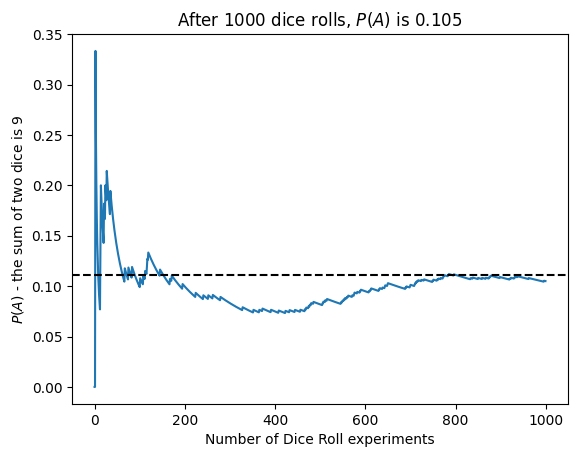

In [20]:
import matplotlib.pyplot as plt
m = 1000 # number of times the experiment is repeated

dice_rolls = []
P_9 = []
total_9s = 0

for i in range(m):
    die_1 = np.random.randint(1, 7)
    die_2 = np.random.randint(1, 7)
    dice_rolls.append(die_1 + die_2)
    total_9s += ((die_1 + die_2)==9)
    P_9.append(float(total_9s) / len(dice_rolls))

plt.plot(list(range(m)), P_9)
plt.axhline(0.111111, color="k", ls="--")
plt.xlabel("Number of Dice Roll experiments")
plt.ylabel("$P(A)$ - the sum of two dice is $9$")
plt.title(f"After {m} dice rolls, $P(A)$ is {P_9[-1]}")
plt.show()

The solid curve corresponds to the $P(A)$ probability, and gives our estimated probability that the sum of the dice is $9$ as assessed after each group of experiments. The dashed black line gives the true underlying probability. As we get more data by conducting more experiments, the solid curve converges towards the true probability.

Let's see how the frequentist probability approaches the classical probability as the number of experiments increases by comparing the charts with $10$, $50$, $100$ and $1000$ experiments.

Since these experiments are generated at random, every execution may give you slighlty different results if you execute the cell below multiple times.

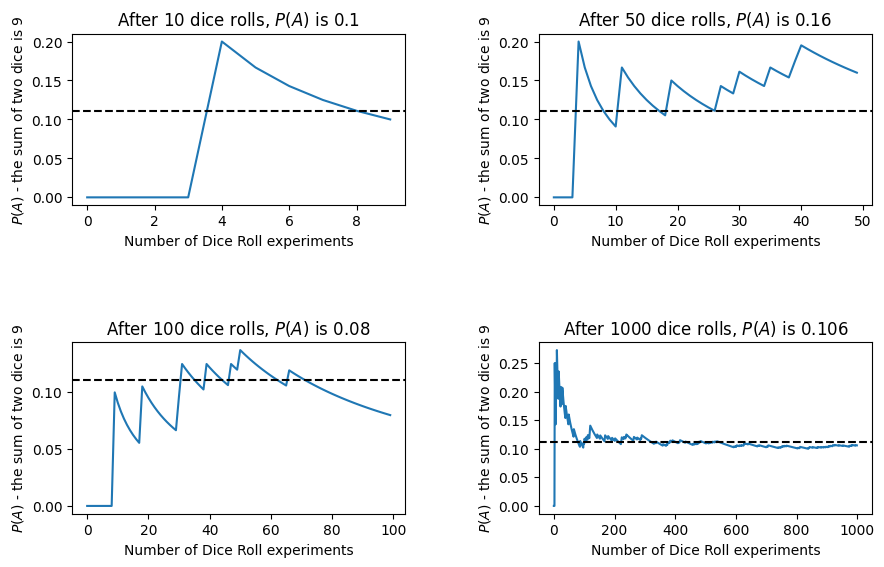

In [16]:
plt.figure(figsize=(10, 6))

m_values = [10, 50, 100, 1000]

for j in range(len(m_values)):
    m = m_values[j]
    plt.subplot(2, 2, j + 1)

    dice_rolls = []
    P_9 = []
    total_9s = 0

    for i in range(m):
        die_1 = np.random.randint(1, 7)
        die_2 = np.random.randint(1, 7)
        dice_rolls.append(die_1 + die_2)
        total_9s += ((die_1 + die_2)==9)
        P_9.append(float(total_9s) / len(dice_rolls))

    plt.plot(list(range(m)), P_9)
    plt.axhline(0.111111, color="k", ls="--")
    plt.xlabel("Number of Dice Roll experiments")
    plt.ylabel("$P(A)$ - the sum of two dice is $9$")
    plt.title(f"After {m} dice rolls, $P(A)$ is {P_9[-1]}")

plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.4,
                    hspace=0.8)
plt.show()

After $1000$ experiments, the frequentist probability converges quite closely to the classical probability value.

<!-- Challenge Box -->
<div style="background-color: #FEF9E7; border-left: 5px solid #F1C40F; padding: 15px; border-radius: 5px; margin: 20px 0; display: flex; align-items: flex-start;">
    <div style="flex: 0 0 60px; margin-right: 15px;">
        <img src="images/mlu-challenge.png" alt="Challenge" width="200" style="max-width: 100%; height: auto;">
    </div>
    <div style="flex: 1;">
        <h4 style="color: #B7950B; margin-top: 0;">Challenge: Coin Toss Probability</h4>
        <p>You may try to generate the frequentist probability chart for the probability of obtaining Head with repeated tosses of a fair coin.</p>
        <p><strong>Your task:</strong> Can you see this converging to the theoretical value of $0.5$?</p>
    </div>
</div>

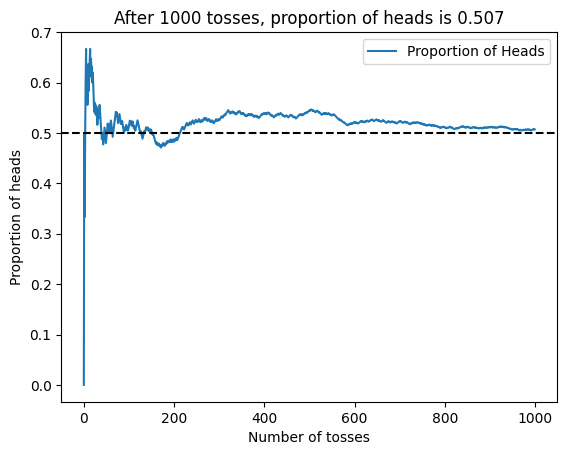

In [27]:
###### YOUR CODE HERE ######

import matplotlib.pyplot as plt
import numpy as np

# Number of coin tosses
n_tosses = 1000

# Simulate coin tosses: 1 = Head, 0 = Tail
tosses = np.random.randint(0, 2, n_tosses)

#Cummulative number of heads
cummulative_heads = np.cumsum(tosses)

# Proportion of heads after each toss
porportions = cummulative_heads / np.arange(1, n_tosses + 1)

#plot
plt.figure ()
plt.plot(porportions, label="Proportion of Heads")
plt.axhline(0.5, color="k", ls="--")
plt.xlabel("Number of tosses")
plt.ylabel("Proportion of heads")
plt.title(f"After {n_tosses} tosses, proportion of heads is {porportions[-1]}")
plt.legend()
plt.show ()


######## END OF CODE ########

<!-- Important Note -->
<div style="background-color: #FDEDEC; border-left: 5px solid #E74C3C; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <p style="color: #C0392B; margin: 0;"><strong>Important:</strong> If you're stuck, remove the <code>#</code> before the <code>load</code> instruction in the next code cell to display sample solutions.</p>
</div>

In [32]:
# %load solutions/lab31_ex1_solutions.txt



<!-- Section Header -->
<div id="section2" style="border-left: 5px solid #2f1381; padding-left: 15px; margin: 40px 0 20px 0;">
    <h2 style="color: #2f1381;">2. Bayes Theorem</h2>
</div>

<!-- Subsection Header -->
<div id="section2-1" style="border-left: 3px solid #4C32E2; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #4C32E2;">2.1 Bayes Theorem: Formulation</h3>
</div>

Using the definition of conditional probabilities,
we can derive the famous result called *Bayes' theorem*.
By construction, we have that $P(A, B) = P(B\mid A) P(A)$
and $P(A, B) = P(A\mid B) P(B)$.
Combining both equations yields
$P(B\mid A) P(A) = P(A\mid B) P(B)$ and hence

$$P(A \mid B) = \frac{P(B\mid A) P(A)}{P(B)}.$$







This simple equation has profound implications because
it allows us to reverse the order of conditioning.
If we know how to estimate $P(B\mid A)$, $P(A)$, and $P(B)$,
then we can estimate $P(A\mid B)$.
We often find it easier to estimate one term directly
but not the other and Bayes' theorem can come to the rescue here.
For instance, if we know the prevalence of symptoms for a given disease,
and the overall prevalences of the disease and symptoms, respectively,
we can determine how likely someone is
to have the disease based on their symptoms.
In some cases we might not have direct access to $P(B)$,
such as the prevalence of symptoms.
In this case a simplified version of Bayes' theorem comes in handy:

$$P(A \mid B) \propto P(B \mid A) P(A).$$

Since we know that $P(A \mid B)$ must be normalized to $1$, i.e., $\sum_a P(A=a \mid B) = 1$,
we can use it to compute

$$P(A \mid B) = \frac{P(B \mid A) P(A)}{\sum_a P(B \mid A=a) P(A = a)}.$$

In Bayesian statistics, we think of an observer
as possessing some (subjective) prior beliefs
about the plausibility of the available hypotheses
encoded in the *prior* $P(H)$,
and a *likelihood function* that says how likely
one is to observe any value of the collected evidence
for each of the hypotheses in the class $P(E \mid H)$.
Bayes' theorem is then interpreted as telling us
how to update the initial *prior* $P(H)$
in light of the available evidence $E$
to produce *posterior* beliefs
$P(H \mid E) = \frac{P(E \mid H) P(H)}{P(E)}$.
Informally, this can be stated as
"posterior equals prior times likelihood, divided by the evidence".
Now, because the evidence $P(E)$ is the same for all hypotheses,
we can get away with simply normalizing over the hypotheses.

<!-- Subsection Header -->
<div id="section2-2" style="border-left: 3px solid #4C32E2; padding-left: 12px; margin: 25px 0 15px 15px;">
    <h3 style="color: #4C32E2;">2.2 Bayes Theorem: Example</h3>
</div>

Let's now look at the same example we saw in the slides.

A common blood test indicates the presence of a disease 95% of the time when the disease is actually present in an individual. Joe's doctor draws some of Joe's blood, and performs the test on his drawn blood. The results indicate that the disease is present in Joe.
Here's the information that Joe's doctor knows about the disease and the diagnostic blood test:
* One-percent people have the disease. That is, if $D$ is the event that a randomly selected individual has the disease, then the probability of $D$ is $0.01$.
* If $H$ is the event that a randomly selected individual is disease-free, that is, healthy, then the probability of $H$ is $1$ minus the probability of $D$, which is $0.99$.
* The **sensitivity** of the test is $0.95$. That is, if a person has the disease, then the probability that the diagnostic blood test comes back positive is $0.95$. This is the probability of testing positive $P$ given the disease $D$ is present.
* The **specificity** of the test is $0.95$. That is, if a person is free of the disease, then the probability that the diagnostic test comes back negative is $0.95$. That is probability of testing negative $N$ given the patient is healthy $H$.

Graphically this can be represented as:

<img style="width: 50%;" src="./images/bayes_example.png"></div>

What is the positive predictive value of the test? That is, given that the blood test is positive for the disease, what is the probability that Joe actually has the disease?

In [33]:
p_d = 0.01
p_h = 0.99

p_pos_given_d = 0.95
p_neg_given_d = 0.05

p_pos_given_h = 0.05
p_neg_given_h = 0.95

def get_p_d_given_pos(p_d, p_h, p_pos_given_d, p_pos_given_h):
    p_d_given_pos = p_pos_given_d * p_d / (p_pos_given_d * p_d + p_pos_given_h * p_h)
    return p_d_given_pos

In [ ]:
get_p_d_given_pos(p_d, p_h, p_pos_given_d, p_pos_given_h)

As seen in the slides, using Bayes Theorem gives us:

$$P(D \mid P) = \frac{P(P\mid D) P(D)}{P(P\mid D) P(D) + P(P\mid H) P(H)} = \frac{(0.95)(0.001)}{(0.95)(0.001)+(0.05)(0.99)} = 0.161$$

What could we improve if we wanted to increase this probability? How can we improve our test in order to increase the precision of our detection? That is, how can we increase the probability of detecting the disease for people who actually carry such disease?

Let's investigate how **$P(D\mid P)$** changes as a function of **test sensitivity** and **test specificity** separately as they range from 90% to 99.9%.

In [ ]:
p_d_given_pos = []

sensitivity_range = np.arange(0.900, 0.999, 0.001)

for sensitivity in sensitivity_range:
    p_d_given_pos.append(get_p_d_given_pos(p_d, p_h, sensitivity, p_pos_given_h))

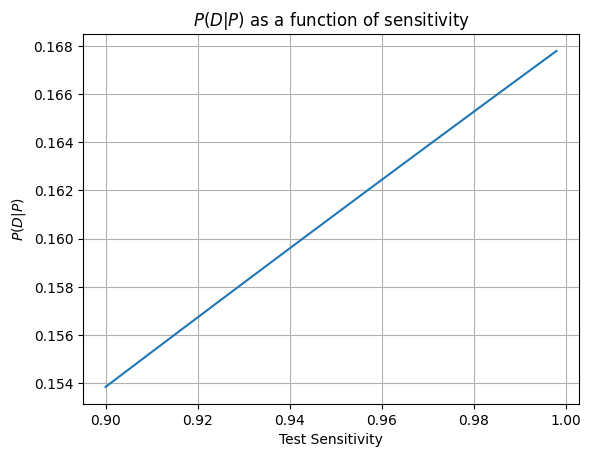

In [35]:
p_d_given_pos = []

sensitivity_range = np.arange(0.900, 0.999, 0.001)

for sensitivity in sensitivity_range:
    p_d_given_pos.append(get_p_d_given_pos(p_d, p_h, sensitivity, p_pos_given_h))

plt.plot(sensitivity_range, p_d_given_pos)
plt.xlabel("Test Sensitivity")
plt.ylabel("$P(D|P)$")
plt.title(f"$P(D|P)$ as a function of sensitivity")
plt.grid()
plt.show()

In [36]:
p_d_given_pos = []

specificity_range = np.arange(0.900, 0.999, 0.001)

for specificity in specificity_range:
    p_d_given_pos.append(get_p_d_given_pos(p_d, p_h, p_pos_given_d, (1-specificity)))

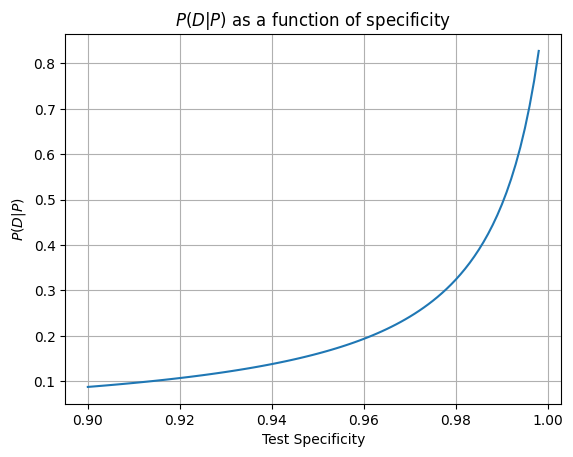

In [37]:
plt.plot(specificity_range, p_d_given_pos)
plt.xlabel("Test Specificity")
plt.ylabel("$P(D|P)$")
plt.title(f"$P(D|P)$ as a function of specificity")
plt.grid()
plt.show()

**Conclusion**: the two plots above show that increasing the sensitivity of the test doesn't yield in major improvements of $P(D\mid P)$, wherease increasing the specificity of the test beyond the 96% mark does rapidly lead to an increase in $P(D\mid P)$ (that is the test detects the disease in patients who are actually carrying it) and therefore that's the direction the research efforts should focus on.

<div style="background-color: #f2f0fc; padding: 15px; border-radius: 5px; margin: 30px 0;">
    <h3 style="color: #2f1381; border-bottom: 1px solid #2f1381; padding-bottom: 5px;">Conclusion</h3>
    <p style="color: #2f1381;">In this lab, you have:</p>
    <ul>
        <li style="color: #2f1381;">Constructed a probability model for the sum of two dice rolls using the classical probability approach</li>
        <li style="color: #2f1381;">Observed how the probability of a repeated experiment approximates the theoretical one (frequentist approach)</li>
        <li style="color: #2f1381;">Explored Bayes theorem on conditional probability using a blood test example</li>
        <li style="color: #2f1381;">Analyzed the effect of test sensitivity and specificity on disease detection accuracy</li>
    </ul>
</div>

<p style="padding: 10px; border: 1px solid black;">
<div style="text-align: right; font-family: Arial;"><hr width="15%" align="right" style="margin-bottom: -0.8em;"><h4>City Colleges of Chicago <h4></div>

# Thank you!